In [100]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt


In [91]:
data = load_iris()


In [92]:
x_train , x_test , y_train , y_test = train_test_split(data.data , data.target , test_size=0.3 , train_size = 0.7 , random_state = 100)

In [93]:
model1 = LogisticRegression()
model1

LogisticRegression()

In [94]:
model2 = DecisionTreeClassifier()
model2

DecisionTreeClassifier()

In [95]:
model3 = SVC()
model3

SVC()

In [96]:
ensemble_model = VotingClassifier(estimators=[('lr', model1), ('dt', model2), ('svc', model3)], voting='hard')
ensemble_model

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()), ('svc', SVC())])

In [97]:
ensemble_model.fit(x_train , y_train)


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()), ('svc', SVC())])

In [98]:
prediction = ensemble_model.predict(x_test)
prediction

array([2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 2, 2,
       0])

In [99]:
print(accuracy_score(y_test , prediction))

0.9777777777777777


In [101]:
import pandas as pd
import seaborn as sns

# Create a DataFrame for easier plotting
iris_df = pd.DataFrame(data.data, columns=data.feature_names)
iris_df['species'] = data.target
iris_df['species_names'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

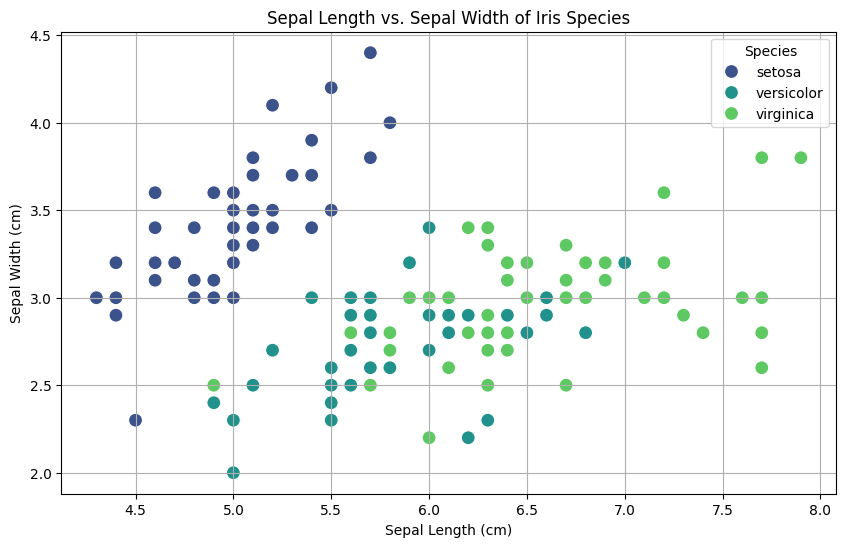

In [102]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species_names', data=iris_df, palette='viridis', s=100)
plt.title('Sepal Length vs. Sepal Width of Iris Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.grid(True)
plt.show()

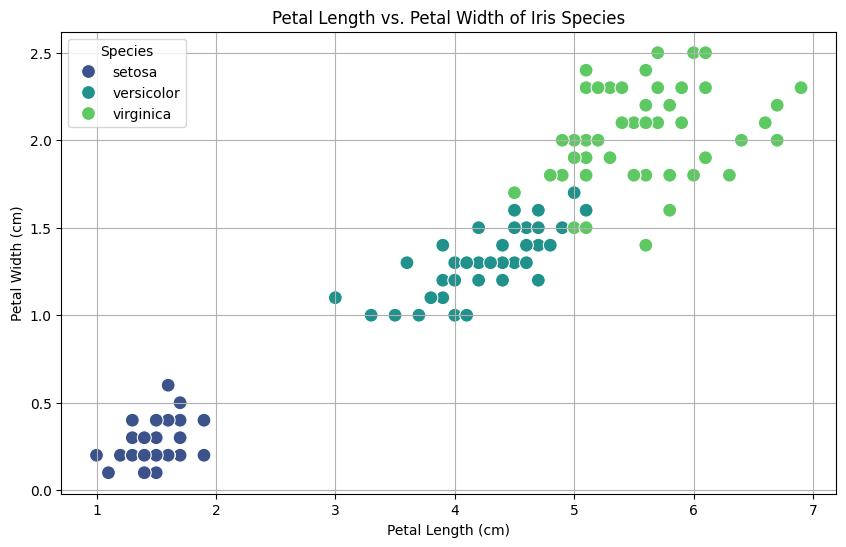

In [103]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species_names', data=iris_df, palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width of Iris Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True)
plt.show()